# Adjacency Permutation Test (neighbourhood enrichment)

The adjacency permutation test (APT) is a statistical framework for quantifying whether particular categorical labels are found adjacent to one another in a spatial network more or less often than expected by chance. In the spatial biology literature, closely related approaches are often referred to as *neighbourhood enrichment* methods; however, we use the more formal term *adjacency permutation test* as this relates to wider network statistics literature.

APT operates on a network that describes spatial interactions between observations, such as cells in tissue. In this network, nodes represent spatial objects (for example cells), while edges define adjacency or interaction relationships according to some spatial rule, such as *k*-nearest neighbours or distance thresholds.

For each pair of categorical labels, for example, cell types or cell states, the test first counts the number of edges connecting nodes with those labels. These observed edge counts capture the degree of spatial association between labels within the network.

To determine whether these associations are statistically meaningful, APT constructs an empirical null distribution through permutation. The categorical labels are randomly shuffled across the network nodes while preserving the underlying spatial network structure, and the edge counts are recomputed after each shuffle. Repeating this process many times (typically around 1000 permutations) produces a null distribution describing the range of edge counts expected under random spatial organisation.

The observed counts can then be compared against this null distribution to assess whether a given pair of labels exhibits:

- **Positive spatial association** (or enrichment): labels are adjacent more often than expected by chance.
- **Negative spatial association** (or exclusion): labels are adjacent less often than expected by chance.

APT provides a convenient way to obtain a global summary of pairwise spatial relationships between labels in a dataset, making it particularly useful for exploratory analysis of tissue organisation and local cellular structure.

In `muspan`, all of this functionality is provided through:

```python
muspan.networks.adjacency_permutation_test()
```

We recommend consulting the function documentation for a full description of available parameters and outputs.

---

In this tutorial, we will first examine a randomly generated dataset to illustrate the behaviour of APT in the absence of spatial correlation. We will then move on to a biologically structured dataset to demonstrate how APT can identify meaningful local label organisation within spatial data.

MuSpAn domain loaded successfully. Domain summary:
Domain name: Density
Number of objects: 2000
Collections: ['Cell centres']
Labels: ['Celltype'] 
Networks: [] 
Distance matrices: []


(<Figure size 1000x800 with 2 Axes>, <Axes: >)

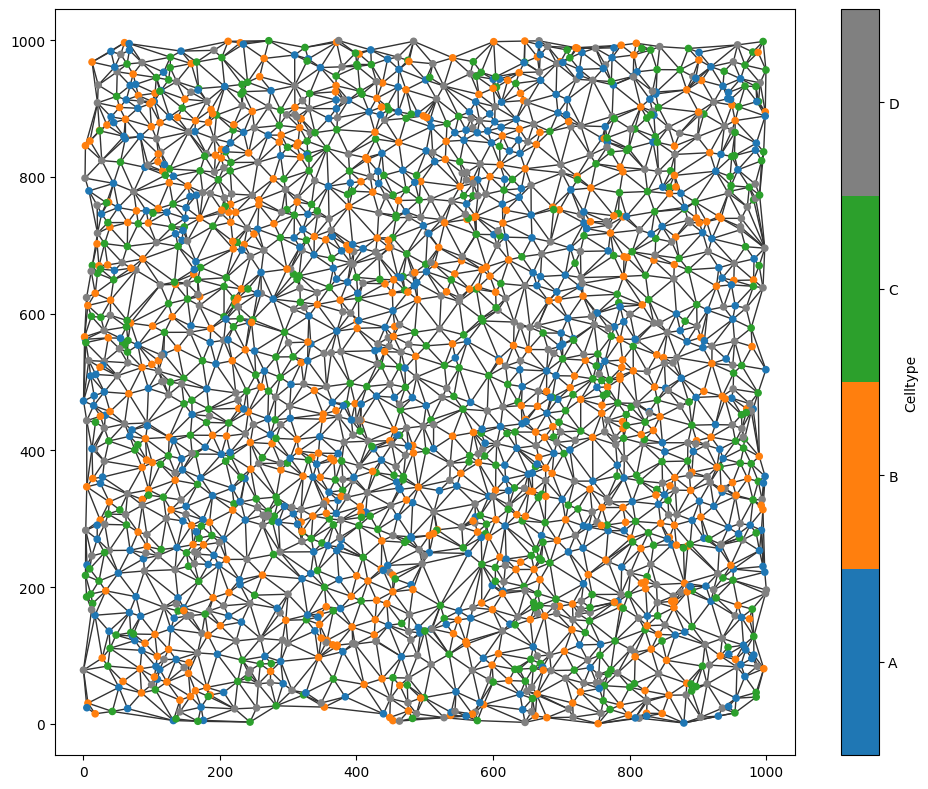

In [17]:
import muspan as ms 
import numpy as np  

# load in the domain of random point with cell type labels
random_domain = ms.datasets.load_example_domain('Synthetic-Points-Random')

# generate a spatial network describing the spatial relationships between the points in the domain
ms.networks.generate_network(random_domain,network_name='DT (<50)',network_type='delaunay',max_edge_distance=100)

# visualise the domain with these labels
ms.visualise.visualise_network(random_domain,network_name='DT (<50)',visualise_kwargs=dict(color_by='Celltype'))
    

We've loaded a random set of points and generated a network describing point-to-point connectivity using a Delaunay triangulation with a maximum edge-length filter. This construction provides a simple model of cell--cell contact between point-like spatial objects.

We can now apply `adjacency_permutation_test()` from the `muspan.networks` submodule to assess whether there is any spatial correlation between the categorical labels assigned to connected nodes.

In [19]:
SES,SES_p_val_filtered,label_categories = ms.networks.adjacency_permutation_test(random_domain,
                                                                                 network_name='DT (<50)',
                                                                                 label_name='Celltype',
                                                                                 alpha=0.05,
                                                                                 label_shuffle_iterations=1000)

We've got three outputs from the function:

- SES : this is a matrix of the standard effect size (correlation) of each label pair 

- SES_p_val_filtered : this is SES but masked to only preserve the correlation that are statistically significant

- label_categories  : the ordered categorical labels to align to the matrix


We can visualise the output SES using the `visualise_correlation_matrix()` function 

The function returns three outputs:

- `SES`: a matrix containing the standardised effect size (SES) for each pair of categorical labels, representing the strength and direction of spatial correlation.

- `SES_p_val_filtered`: the SES matrix filtered by statistical significance, where non-significant correlations have been masked.

- `label_categories`: the ordered categorical labels corresponding to the rows and columns of the matrices.

We can visualise the `SES` output using the `visualise_correlation_matrix()` function.

(<Figure size 1000x800 with 2 Axes>, <Axes: >)

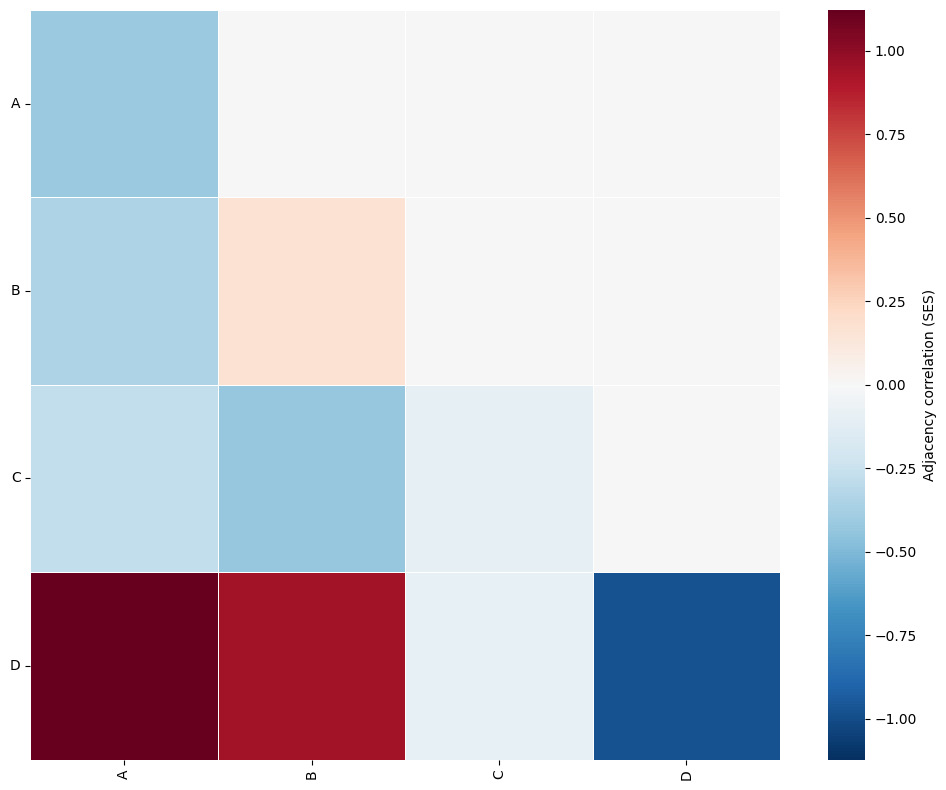

In [29]:
ms.visualise.visualise_correlation_matrix(np.tril(SES),label_categories,colorbar_label='Adjacency correlation (SES)')

We can now examine which of these interactions are statistically significant. The SES values correspond to *z*-scores, meaning that correlations with magnitude greater than approximately `1.96` are significant at \(\alpha = 0.05\).

In this example, none of the observed correlations appear to exceed this threshold, suggesting that there is no statistically significant spatial association between labels in the random dataset.

We can confirm this by visualising the `SES_p_val_filtered` matrix, which masks correlations that do not pass the corrected significance threshold.

(<Figure size 1000x800 with 2 Axes>, <Axes: >)

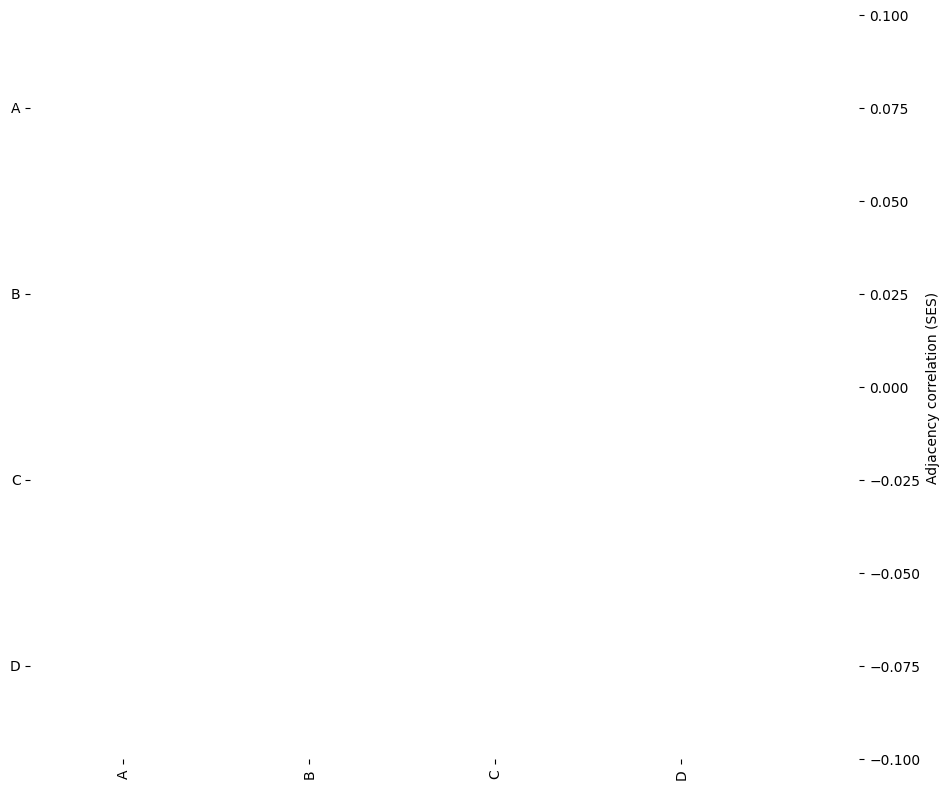

In [32]:
ms.visualise.visualise_correlation_matrix(SES_p_val_filtered,label_categories,colorbar_label='Adjacency correlation (SES)')

No significant interactions are visible in the filtered matrix. For this network model and significance threshold, the adjacency permutation test suggests that there is no detectable spatial correlation between any pair of cell types.

---

Let us now apply the APT to a second spatial dataset in which the underlying spatial structure is more apparent.

MuSpAn domain loaded successfully. Domain summary:
Domain name: Architecture
Number of objects: 5991
Collections: ['Cell centres']
Labels: ['Celltype'] 
Networks: [] 
Distance matrices: []


(<Figure size 1000x800 with 2 Axes>, <Axes: >)

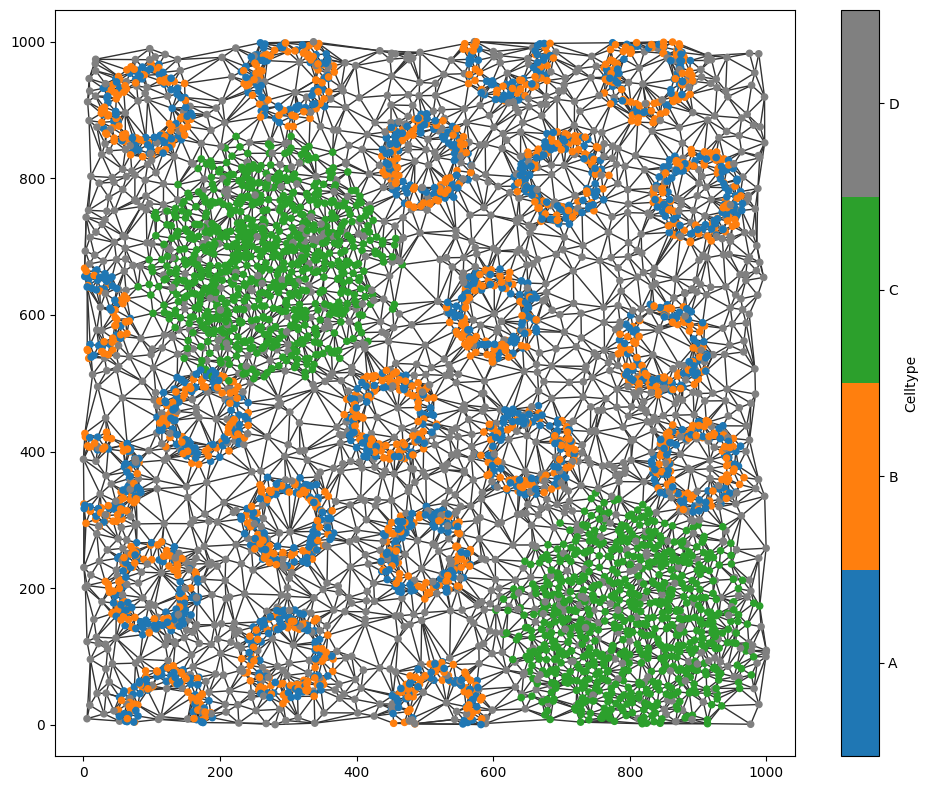

In [27]:
# load in the domain of random point with cell type labels
structured_domain = ms.datasets.load_example_domain('Synthetic-Points-Architecture')

# generate a spatial network describing the spatial relationships between the points in the domain
ms.networks.generate_network(structured_domain,network_name='DT (<50)',network_type='delaunay',max_edge_distance=100)

# visualise the domain with these labels
ms.visualise.visualise_network(structured_domain,network_name='DT (<50)',visualise_kwargs=dict(color_by='Celltype'))

In this synthetic dataset, we can visually observe that labels `A` and `B` are frequently located near one another, while points labelled `C` tend to cluster predominantly with other `C` points. We can now test whether these spatial patterns are detected by the adjacency permutation test.

Here, we will also make use of the convenient `visualise_output` parameter, which automatically plots the SES matrix filtered by statistical significance.

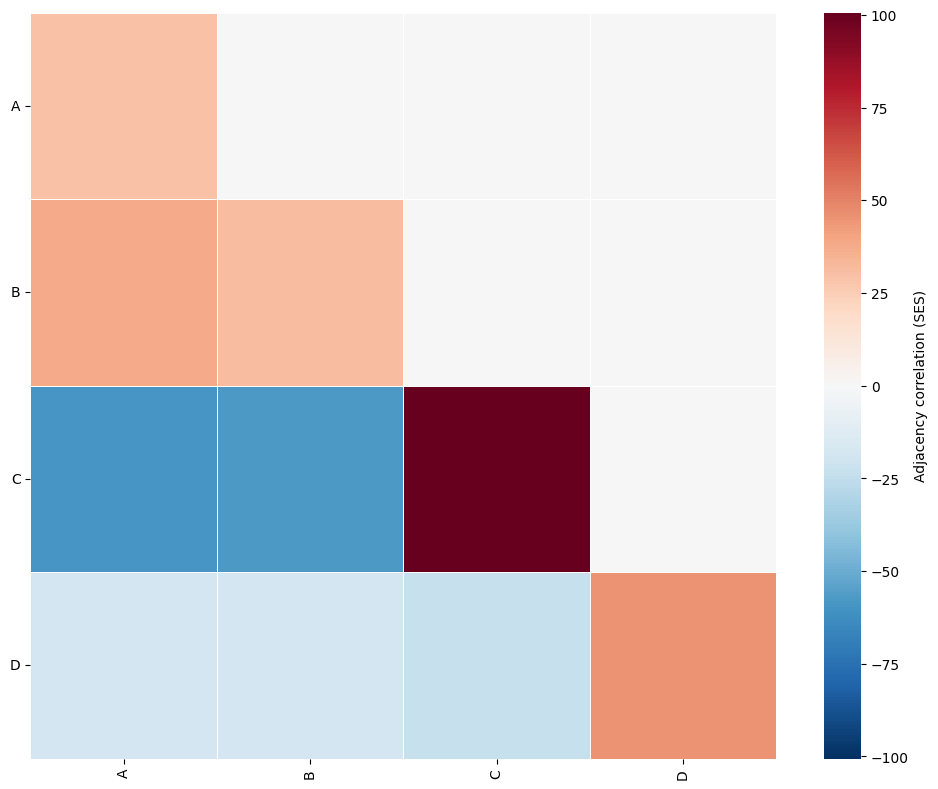

In [33]:
SES_structured,SES_p_val_filtered_structured,label_categories_structured = ms.networks.adjacency_permutation_test(structured_domain,
                                                                                                                network_name='DT (<50)',
                                                                                                                label_name='Celltype',
                                                                                                                alpha=0.05,
                                                                                                                label_shuffle_iterations=1000,
                                                                                                                visualise_output=True,
                                                                                                                visualise_correlation_matrix_kwargs=dict(colorbar_label='Adjacency correlation (SES)'))

As expected, the adjacency permutation test identifies that labels `A` and `B` are both homotypically and heterotypically positively correlated. This indicates that nodes with labels `A` and `B` are found adjacent to one another more frequently than expected under random label assignment.

In addition, nodes labelled `C` show a strong positive correlation with other `C` nodes and negative correlations with all other label categories. Quantitatively, this reflects the presence of homotypic `C` clusters within this synthetic spatial dataset.

Importantly, all of these detected correlations are statistically significant.

---

In this tutorial, we demonstrated how the adjacency permutation (APT) test can be applied to a spatial network to identify correlations between adjacent categorical labels, such as cell types. We also encourage exploring how different network constructions and parameter choices influence the definition of spatial interactions, and consequently the behaviour and interpretation of the permutation test.